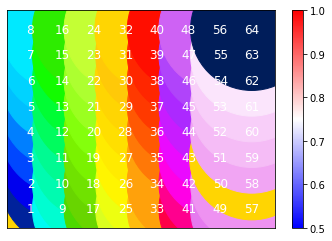

In [87]:
         


     
# Make Community Color list
community_num_group = len(max_k_w)
color_list_community = [[] for i in range(len(G.nodes()))] # list comprehension. empty list of list

for i in range(len(G.nodes())):
   for j in range(community_num_group):
       if i in max_k_w[j]:
           color_list_community[i] = j
           

# Plot Community           
fig, ax = plt.subplots()
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
Feature_color_sub = color_list_community

d = dict(G.degree)
node_size_normalized = np.fromiter(d.values(), dtype = float)
node_size_normalized = (node_size_normalized - np.min(node_size_normalized))/(np.max(node_size_normalized) - np.min(node_size_normalized))
nx.draw_networkx_nodes(
    G=G,
    pos = pos,
    node_size = 500 * (30 + node_size_normalized),
    node_color=Feature_color_sub,
    cmap='gist_ncar',
    vmin=0,
    vmax=community_num_group,
    ax = ax )

nx.draw_networkx_labels(
    G=G,
    pos = pos,
    font_color = "white",
    ax = ax )

edges = nx.draw_networkx_edges(
    G = G,
    pos = pos,
    edge_color = weights,
    width = 1.5,
    edge_cmap = plt.cm.bwr,
    ax = ax)
        #    %pyrun("plt.xticks([])")
        #    %pyrun("plt.yticks([])")
plt.colorbar(edges)
        #    %pyrun("plt.show(block=False)")

fig.savefig('networkfig.png')

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import copy
from networkx.algorithms import community
import matplotlib.animation as animation
import community as lvcm
import scipy
import pickle
import pandas as pd  

In [74]:
#1.  create network.
distMat = np.load("score_matrix.npy")
#print(distMat)
positions = pd.read_pickle("positions.pkl")

In [79]:
np.set_printoptions(threshold=sys.maxsize)
distMat[1,]

array([       nan, 0.        ,        nan,        nan, 0.57142857,
       0.44444444, 0.25      , 0.61538462, 0.57142857,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan, 0.        , 0.        , 0.        ,
              nan, 0.        , 0.        ,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan, 0.57142857,        nan,
              nan,        nan,        nan,        nan])

array([nan,  0., nan, nan,  0.,  0.,  0.,  0.,  0., nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,  0.,  0.,
        0., nan,  0.,  0., nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan,  0., nan, nan, nan, nan, nan])

In [78]:
# graph는 제대로 작성된 것 같다.
print(G["2"]["5"]["weight"])
print(G["2"]["8"]["weight"])
print(G["2"]["9"]["weight"])
print(G["2"]["59"]["weight"])




0.5714285714285714
0.6153846153846154
0.5714285714285714
0.5714285714285714


In [65]:
#print(positions)
n_nodes = distMat.shape[1] # number of nodes = number of channels
G = nx.Graph()

# We set the electrode as a node (e.g., circles in the network map)
channel_list = ["{}".format(int(i)) for i in positions[0]]
#print(channel_list)
#G.add_nodes_from(channel_list)

#pos = {}
for i in range(len(channel_list)):
    x_now = positions.iloc[i, 1]
    y_now = positions.iloc[i, 2]
    position_now = (int(x_now), int(y_now))
    G.add_node(channel_list[i], pos = position_now )
    #pos[channel_list[i]] = position_now
pos=nx.get_node_attributes(G,'pos')
#print(pos)
# we set the degree of synchronization between the electrodes as an edge
# (e.g., lines in the network map).
for i in range(n_nodes):
    for j in range(i+1, n_nodes):
        sync_score = distMat[i,j]
        # the links with synchronized scores less than 0.5 were filtered out.
        if sync_score >= 1/2:
            
            G.add_edge(channel_list[i], channel_list[j], weight = sync_score)


In [19]:
# Louvain method
partition = lvcm.best_partition(graph=G, partition=None, random_state = 1)
max_k_w = []
for com in set(partition.values()):
    list_nodes = [nodes for nodes in partition.keys() if partition[nodes] == com]
    list_nodes = [channel_list.index(node) for node in list_nodes]
    max_k_w = max_k_w + [list_nodes]
     # list comprehension. concat [member list] of each community

In [86]:
partition

{'channel1': 0,
 'channel2': 33,
 'channel3': 2,
 'channel4': 3,
 'channel5': 33,
 'channel6': 4,
 'channel7': 4,
 'channel8': 4,
 'channel9': 33,
 'channel10': 5,
 'channel11': 6,
 'channel12': 7,
 'channel13': 8,
 'channel14': 9,
 'channel15': 10,
 'channel16': 11,
 'channel17': 12,
 'channel18': 13,
 'channel19': 14,
 'channel20': 15,
 'channel21': 16,
 'channel22': 17,
 'channel23': 18,
 'channel24': 19,
 'channel25': 20,
 'channel26': 21,
 'channel27': 22,
 'channel28': 23,
 'channel29': 24,
 'channel30': 25,
 'channel31': 26,
 'channel32': 27,
 'channel33': 28,
 'channel34': 29,
 'channel35': 30,
 'channel36': 31,
 'channel37': 32,
 'channel38': 33,
 'channel39': 34,
 'channel40': 33,
 'channel41': 35,
 'channel42': 36,
 'channel43': 36,
 'channel44': 37,
 'channel45': 38,
 'channel46': 39,
 'channel47': 40,
 'channel48': 41,
 'channel49': 42,
 'channel50': 43,
 'channel51': 44,
 'channel52': 45,
 'channel53': 46,
 'channel54': 47,
 'channel55': 48,
 'channel56': 49,
 'channel57'